In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import keras
import tensorflow as tf
from keras import layers
from tensorflow.keras import regularizers

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

I0000 00:00:1774441961.318694  402465 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774441961.792731  402465 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774441963.385932  402465 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/metriics/nltk_data...
[nltk_data]   Package stopwords is already up

True

## Data

In [3]:
df = pd.read_csv("Sent2lab.csv", encoding="utf-8")

In [4]:
df

,Unnamed: 0,text,sentiment
0,43956,Развода на деньги нет\nНаблюдаюсь в Лайфклиник...,1
1,17755,Отель выбрали потому что рядом со стадионом. О...,0
2,20269,"Вылечили\nГноился с рождения глазик, в поликли...",1
3,16648,Хорошее расположение.С вокзала дошли пешком.Но...,0
4,27879,"Отличное месторасположение,прекрасный вид,особ...",1
...,...,...,...
210984,22100,"Мой юбилей я отмечал в ресторане "" Астория "" ....",2
210985,2326,"Отлично встретили, разместили в роскошном номе...",1
210986,10478,Была в Васаби на ст. метро Сенная . Во первых...,0
210987,4028,Ребята не стоит смотреть этот фильм. Вы молоды...,0


In [5]:
df_1 = df[df["sentiment"] == 1].iloc[6000:23456]
df_0 = df[df["sentiment"] == 2].iloc[6000:23321]
df_0["sentiment"] = 0

Ndf = pd.concat([df_0, df_1], ignore_index=True)
Ndf = Ndf.sample(frac=1, random_state=41, ignore_index=True)
Ndf = Ndf.drop(["Unnamed: 0"], axis=1)

In [6]:
Ndf

,text,sentiment
0,Какая переклейка? Вернула вторую кастрюлю с пе...,0
1,Вернулся я из Стамбула: город мне не понравилс...,1
2,Стоматология на территории Морозовской больниц...,0
3,Отличный врач\nУра! Наконец-то я нашла своего ...,1
4,побили представителя власти. 2. На рынк...,0
...,...,...
34772,Данная мадам попала ко мне в руки не то чтобы ...,1
34773,Первые волонтеры появились в XIX веке: ини...,1
34774,ЭКО\nХочу поблагодарить Киндарову Лейлу Бароно...,1
34775,Отмечали юбилей . Танцевали до упада . Еда н...,0


label: The sentiment label, where:

    0: Neutral
    1: Positive
    2: Negative

In [7]:
def cleanText(doc):
    doc = doc.replace('\n', ' ').strip()
    return doc

Ndf["text"] = Ndf["text"].apply(lambda x: cleanText(x))

## Tokenize

In [105]:
X = Ndf["text"]
y = Ndf["sentiment"]

In [106]:
y.shape

(34777,)

In [107]:
X.shape

(34777,)

In [108]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    max_features=128,
    ngram_range=(1, 2),
    stop_words=stopwords.words('russian')
)

X = vectorizer.fit_transform(X).toarray()

In [109]:
X.shape

(34777, 128)

In [110]:
X 

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.14848127]])

In [111]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [112]:
X

array([[-0.25805072, -0.17267603, -0.20148843, ..., -0.21457515,
        -0.23605599, -0.58881636],
       [-0.25805072, -0.17267603, -0.20148843, ..., -0.21457515,
        -0.23605599, -0.58881636],
       [-0.25805072, -0.17267603, -0.20148843, ..., -0.21457515,
        -0.23605599, -0.58881636],
       ...,
       [-0.25805072, -0.17267603, -0.20148843, ..., -0.21457515,
        -0.23605599, -0.58881636],
       [-0.25805072, -0.17267603, -0.20148843, ..., -0.21457515,
        -0.23605599, -0.58881636],
       [-0.25805072, -0.17267603, -0.20148843, ..., -0.21457515,
        -0.23605599,  0.33019729]])

In [113]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=0.7, random_state=1, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=0.7, random_state=1, stratify=y_temp)

In [114]:
X_train.shape, X_val.shape, X_test.shape

((24343, 128), (7303, 128), (3131, 128))

In [115]:
y_train.value_counts()

sentiment
1    12219
0    12124
Name: count, dtype: int64

In [116]:
y_val.value_counts()

sentiment
1    3665
0    3638
Name: count, dtype: int64

In [117]:
y_test.value_counts()

sentiment
1    1572
0    1559
Name: count, dtype: int64

In [118]:
batch_size = 32

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_ds = train_ds.shuffle(5000).batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

In [119]:
for x, y in train_ds.take(1):
    print(x)
    print(y)

tf.Tensor(
[[-0.25805072 -0.17267603 -0.20148843 ... -0.21457515  4.39364448
   0.71103118]
 [-0.25805072 -0.17267603 -0.20148843 ... -0.21457515 -0.23605599
  -0.58881636]
 [-0.25805072 -0.17267603 -0.20148843 ... -0.21457515 -0.23605599
  -0.58881636]
 ...
 [-0.25805072 -0.17267603 -0.20148843 ... -0.21457515 -0.23605599
   0.51623782]
 [-0.25805072 -0.17267603 -0.20148843 ... -0.21457515 -0.23605599
   0.22649639]
 [-0.25805072 -0.17267603 -0.20148843 ... -0.21457515 -0.23605599
  -0.58881636]], shape=(32, 128), dtype=float64)
tf.Tensor([0 0 1 0 0 0 0 1 1 0 1 0 1 0 0 0 1 0 1 1 1 0 0 1 0 1 1 0 0 1 0 0], shape=(32,), dtype=int64)


## Modeling

In [120]:
inputs = keras.Input(shape=(128,))

x = layers.Dense(32, activation="relu")(inputs) 
x = layers.Dropout(0.3)(x)

x = layers.Dense(16, activation="relu")(x)
x = layers.Dropout(0.3)(x)

# output layer
predictions = layers.Dense(1, activation="sigmoid", name="predictions")(x)

model = keras.Model(inputs, predictions)

In [121]:
optimizer = keras.optimizers.Adam(learning_rate=0.001)

model.compile(loss=keras.losses.BinaryCrossentropy(), optimizer=optimizer, metrics=["accuracy"])

In [122]:
epochs = 100

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",   # следим за ошибкой на валидации
    patience=10,          # ждём 7 эпох без улучшения
    restore_best_weights=True  # возвращаем лучшие веса
)

history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=[early_stop])

Epoch 1/100
761/761 ━━━━━━━━━━━━━━━━━━━━ 1s 987us/step - accuracy: 0.6678 - loss: 0.6057 - val_accuracy: 0.7434 - val_loss: 0.5089
Epoch 2/100
761/761 ━━━━━━━━━━━━━━━━━━━━ 1s 942us/step - accuracy: 0.7435 - loss: 0.5119 - val_accuracy: 0.7563 - val_loss: 0.4812
Epoch 3/100
761/761 ━━━━━━━━━━━━━━━━━━━━ 1s 891us/step - accuracy: 0.7615 - loss: 0.4909 - val_accuracy: 0.7649 - val_loss: 0.4695
Epoch 4/100
761/761 ━━━━━━━━━━━━━━━━━━━━ 1s 965us/step - accuracy: 0.7675 - loss: 0.4748 - val_accuracy: 0.7693 - val_loss: 0.4608
Epoch 5/100
761/761 ━━━━━━━━━━━━━━━━━━━━ 1s 913us/step - accuracy: 0.7746 - loss: 0.4657 - val_accuracy: 0.7728 - val_loss: 0.4553
Epoch 6/100
761/761 ━━━━━━━━━━━━━━━━━━━━ 1s 944us/step - accuracy: 0.7761 - loss: 0.4625 - val_accuracy: 0.7753 - val_loss: 0.4541
Epoch 7/100
761/761 ━━━━━━━━━━━━━━━━━━━━ 1s 972us/step - accuracy: 0.7835 - loss: 0.4530 - val_accuracy: 0.7791 - val_loss: 0.4498
Epoch 8/100
761/761 ━━━━━━━━━━━━━━━━━━━━ 1s 978us/step - accuracy: 0.7841 - loss: 0

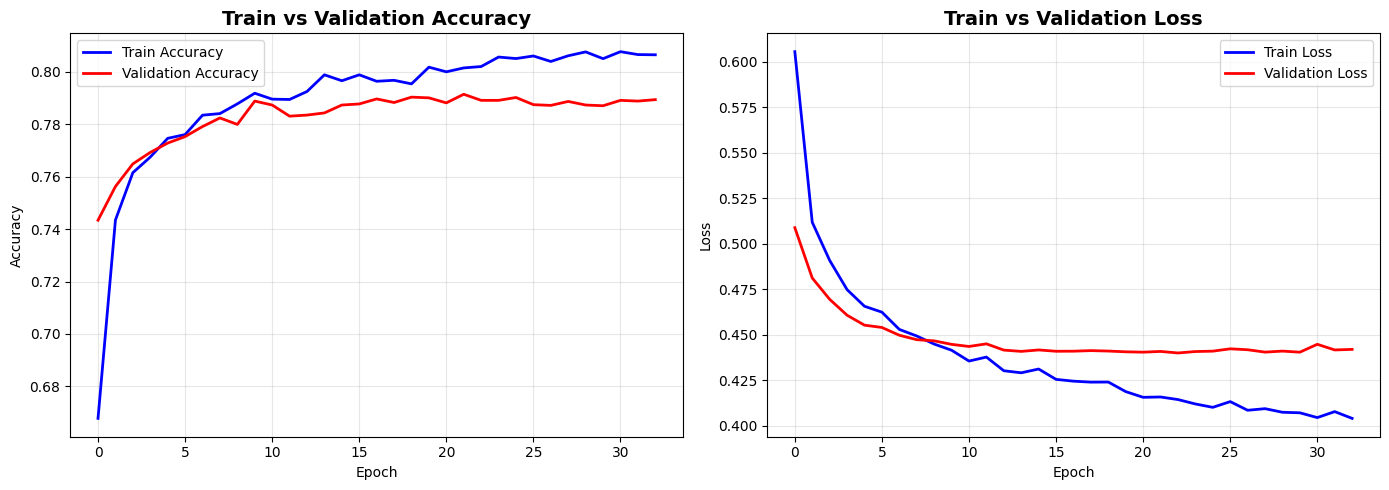

In [123]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], 'b-', linewidth=2, label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], 'r-', linewidth=2, label='Validation Accuracy')
ax1.set_title('Train vs Validation Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'], 'b-', linewidth=2, label='Train Loss')
ax2.plot(history.history['val_loss'], 'r-', linewidth=2, label='Validation Loss')
ax2.set_title('Train vs Validation Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Scoring

In [125]:
model.evaluate(test_ds)

98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 681us/step - accuracy: 0.7927 - loss: 0.4492


[0.4491744339466095, 0.7927179932594299]

In [127]:
y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()

f1  = f1_score(y_test, y_pred)
pre = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

print(f"F1-score:  {f1:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall:    {rec:.4f}")

F1-score:  0.7787
Precision: 0.8391
Recall:    0.7265
